## 전처리

In [3]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [4]:
df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv")
test_df = df.copy()
test_df.shape

(22308, 73)

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

price_clean = test_df['price'].replace(r'[\$,]', '', regex=True)

price_float = pd.to_numeric(price_clean, errors='coerce')

price_float.isna().sum()
#결측치가 없으므로 int로 변환

np.int64(0)

In [6]:
test_df['price'] = test_df['price'].replace(r'[\$,]', '', regex=True).astype(float).astype(int)
test_df['price']

0          200
1           82
2          765
3          139
4          130
5          139
6           96
7           59
8           67
9          195
10         290
11         216
12         165
13         150
14         171
15         150
16          62
17         100
18         563
19         185
20         165
21         110
22          77
23         175
24          90
25         110
26         115
27         169
28          97
29         109
30         534
31          60
32          97
33         260
34         114
35          81
36         161
37         175
38          95
39          60
40          57
41          85
42          95
43         136
44         300
45         230
46          70
47         150
48         200
49          94
50         153
51         117
52         110
53          90
54          99
55         156
56         266
57         223
58         298
59         172
60          87
61          86
62         125
63          85
64         150
65         200
66        

In [7]:
# 상관계수 구하기
pearson_corr = test_df['number_of_reviews'].corr(test_df['price'], method='pearson')
spearman_corr = test_df['number_of_reviews'].corr(test_df['price'], method='spearman')

print(f"피어슨 상관계수 (직선적 관계): {pearson_corr:.4f}")
print(f"스피어만 상관계수 (순위 기반): {spearman_corr:.4f}")

피어슨 상관계수 (직선적 관계): -0.0517
스피어만 상관계수 (순위 기반): -0.0868


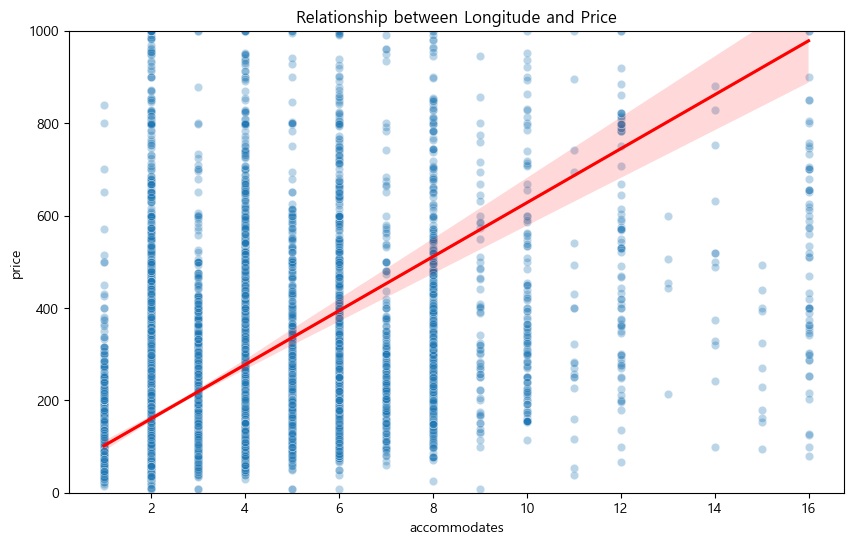

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_df, x='accommodates', y='price', alpha=0.3)

# 추세선 추가 (데이터의 전체적인 흐름 확인)
sns.regplot(data=test_df, x='accommodates', y='price', scatter=False, color='red')

plt.title('Relationship between Longitude and Price')
plt.ylim(0, 1000) # 가격이 너무 높은 이상치 때문에 그래프가 뭉개지는 것 방지
plt.show()

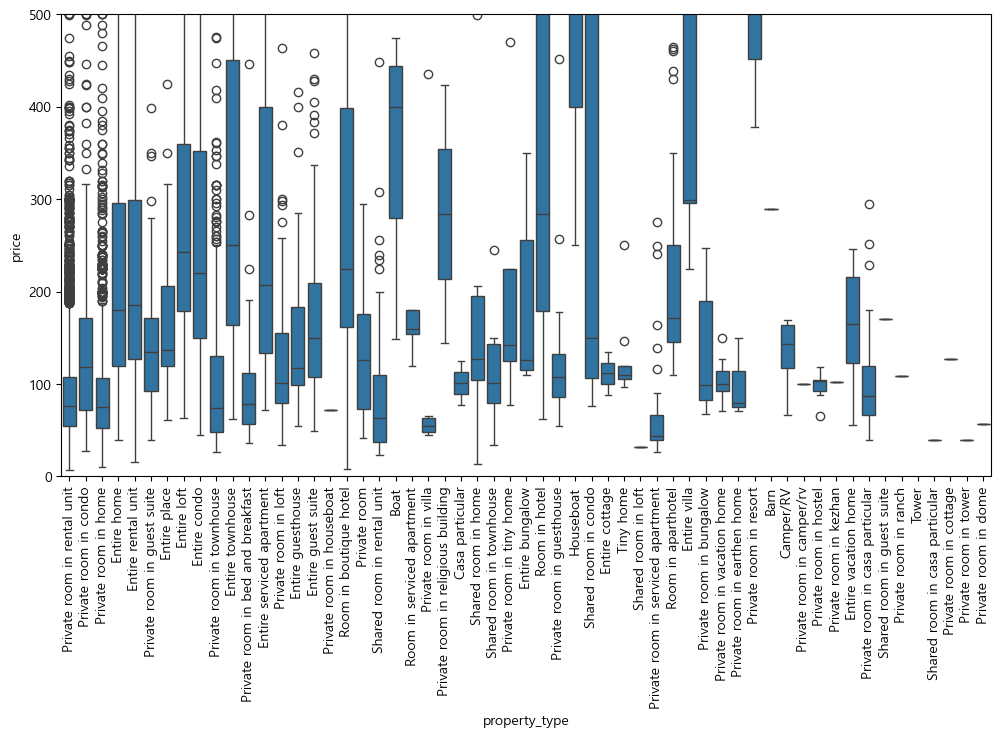

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='property_type', y='price', data=test_df)
plt.xticks(rotation=90)
plt.ylim(0, 500)        # 가격 범위 제한
plt.show()

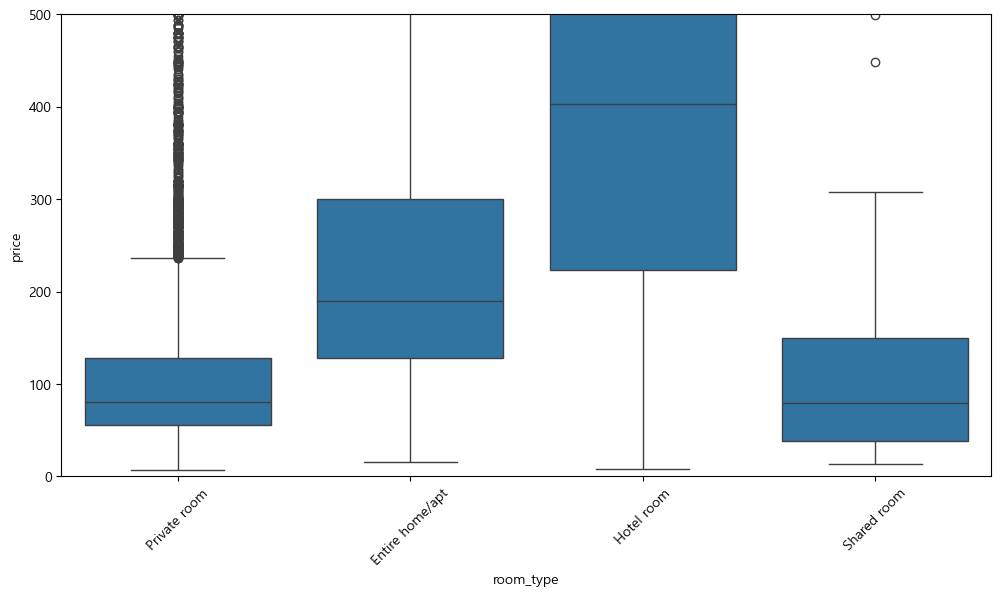

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='room_type', y='price', data=test_df)
plt.xticks(rotation=45)
plt.ylim(0, 500)        # 가격 범위 제한
plt.show()

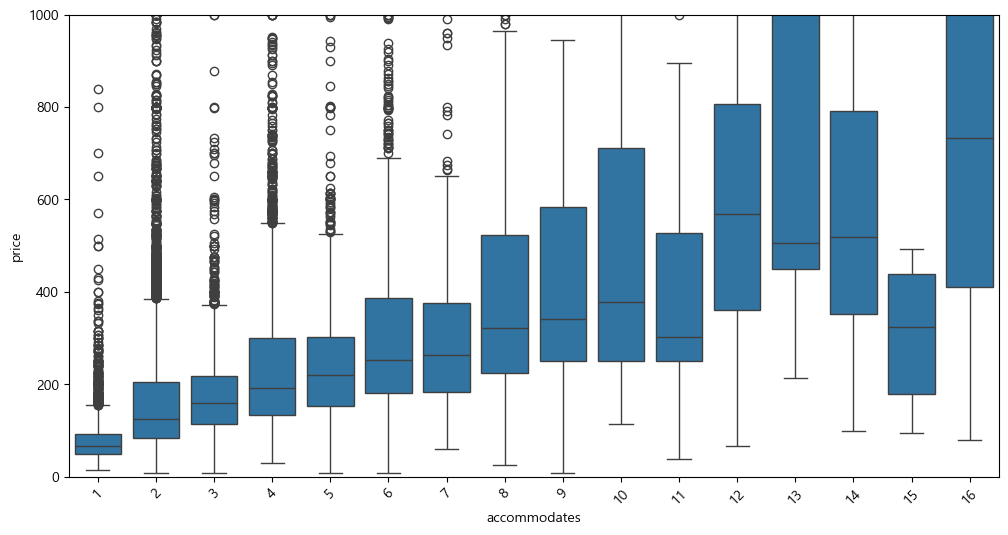

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='accommodates', y='price', data=test_df)
plt.xticks(rotation=45)
plt.ylim(0, 1000)        # 가격 범위 제한
plt.show()

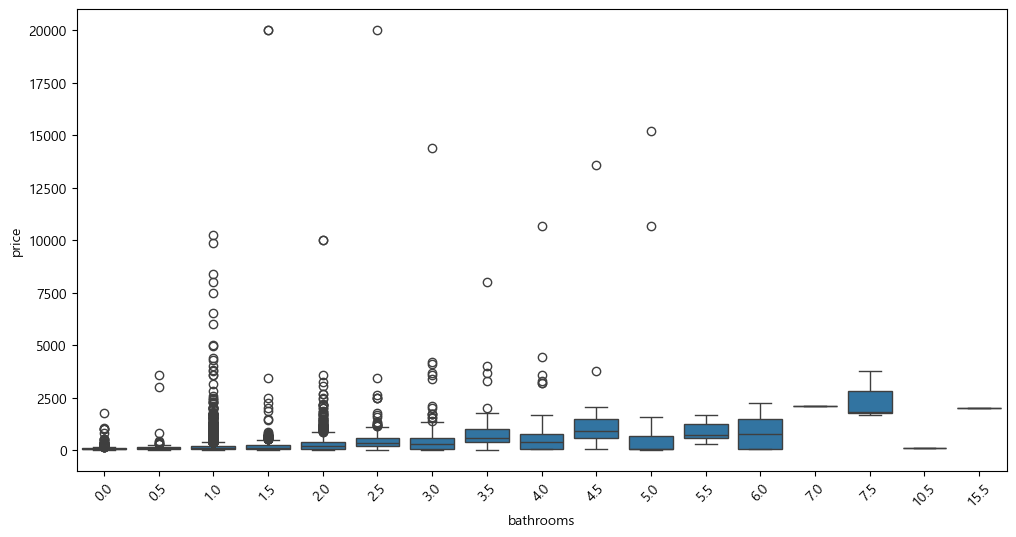

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='bathrooms', y='price', data=test_df)
plt.xticks(rotation=45)
#plt.ylim(0, 1000)        # 가격 범위 제한
plt.show()

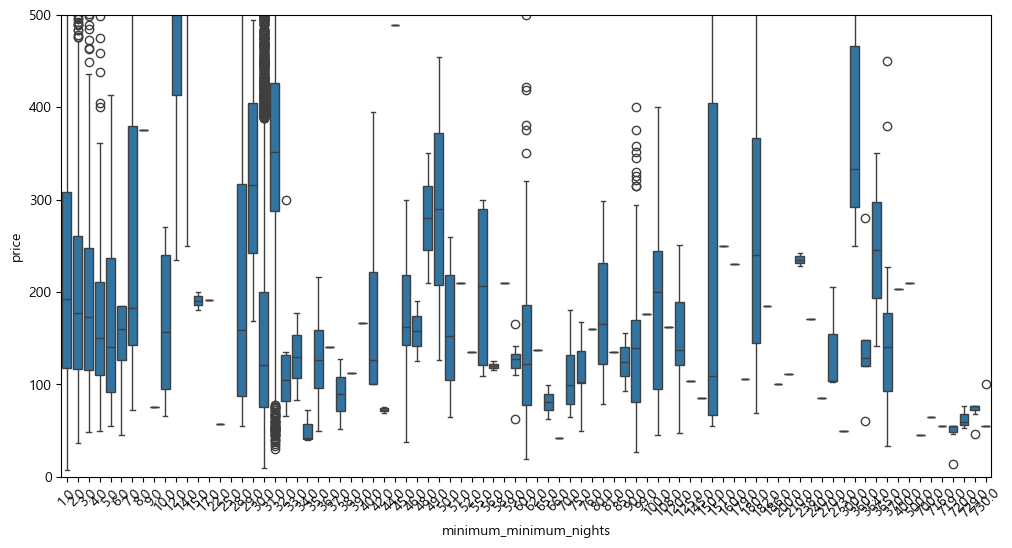

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='minimum_minimum_nights', y='price', data=test_df)
plt.xticks(rotation=45)
plt.ylim(0, 500)        # 가격 범위 제한
plt.show()

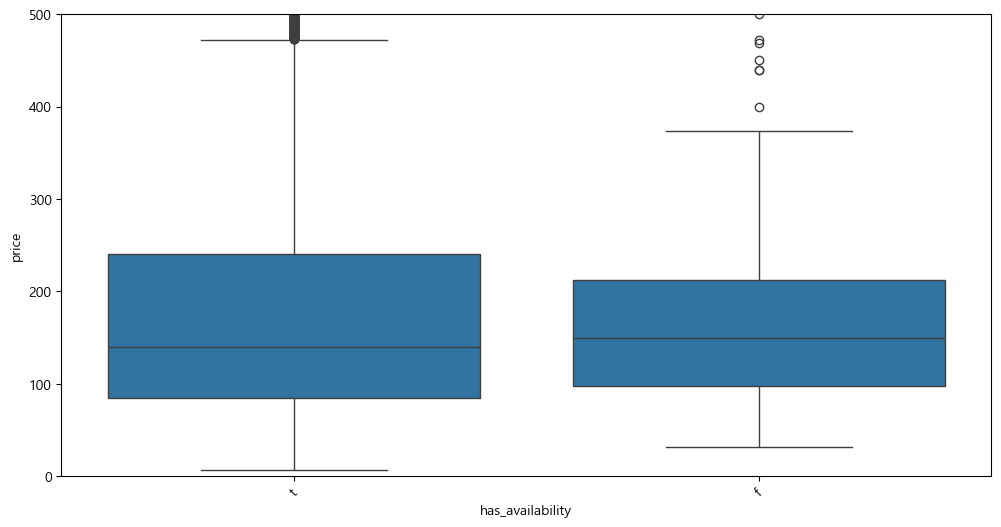

In [14]:
test_avail = test_df.copy()
test_avail['has_availability']=test_df['has_availability'].fillna('f')
plt.figure(figsize=(12, 6))
sns.boxplot(x='has_availability', y='price', data=test_avail)
plt.xticks(rotation=45)
plt.ylim(0, 500)        # 가격 범위 제한
plt.show()

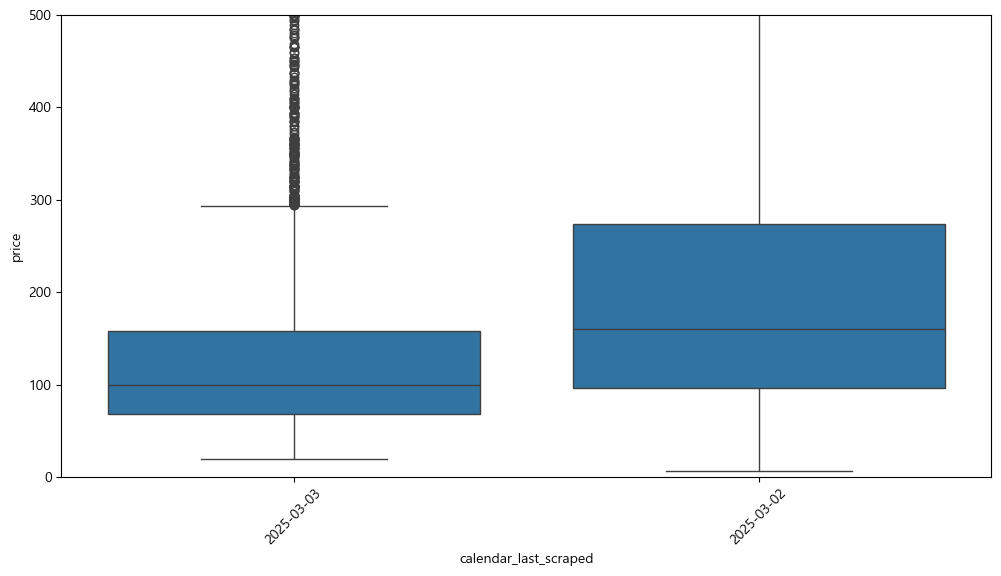

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='calendar_last_scraped', y='price', data=test_avail)
plt.xticks(rotation=45)
plt.ylim(0, 500)        # 가격 범위 제한
plt.show()

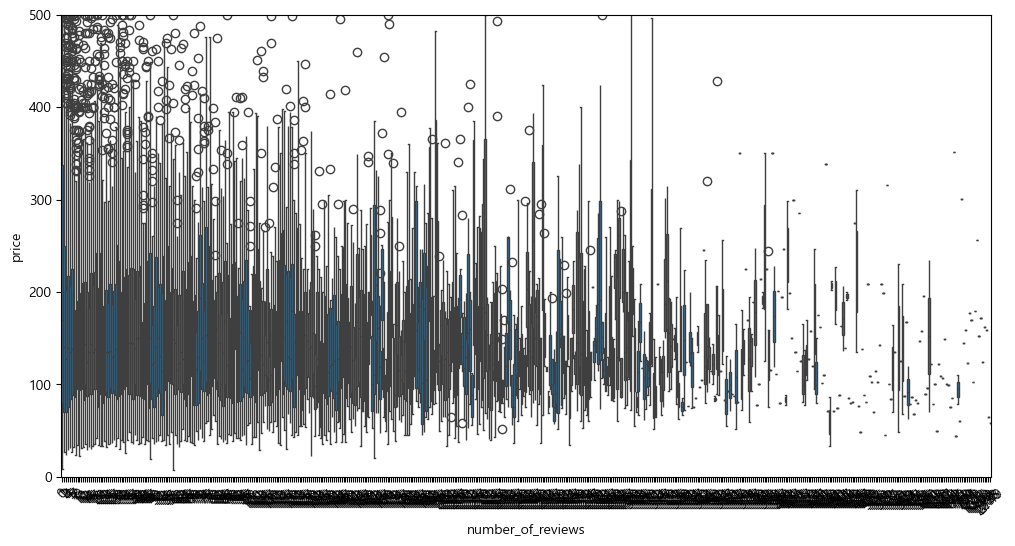

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='number_of_reviews', y='price', data=test_avail)
plt.xticks(rotation=45)
plt.ylim(0, 500)        # 가격 범위 제한
plt.show()

In [17]:
col_isna = test_df['has_availability'].isna().sum()
col_dup = test_df['has_availability'].duplicated().sum()
col_vc = test_df['has_availability'].value_counts()
print(f"isna : {col_isna}")
print(f"duplicate : {col_dup}")
print(f"vc : {col_vc}")

isna : 246
duplicate : 22306
vc : has_availability
t    22062
Name: count, dtype: int64


In [18]:
# 1. 25~50번째 컬럼 슬라이싱 + price 포함
target_columns = list(test_df.columns[25:51]) 
if 'price' not in target_columns:
    target_columns.append('price')

# 2. 그 중 수치형 데이터만 추출
numeric_df = test_df[target_columns].select_dtypes(include=['number'])

# 3. 스피어만 상관계수 계산 (이상치에 강함)
price_corr = numeric_df.corr(method='spearman')['price'].sort_values(ascending=False)

print("--- 가격과 상관관계가 높은 주요 변수 ---")
print(price_corr.head(20))

--- 가격과 상관관계가 높은 주요 변수 ---
price                     1.000000
accommodates              0.557199
beds                      0.402832
bedrooms                  0.294062
bathrooms                 0.147161
maximum_nights            0.098611
maximum_maximum_nights    0.095050
availability_365          0.064370
maximum_nights_avg_ntm    0.058891
minimum_maximum_nights    0.021151
availability_30           0.000054
availability_90          -0.024925
availability_60          -0.028720
maximum_minimum_nights   -0.036713
minimum_nights_avg_ntm   -0.048323
minimum_minimum_nights   -0.048967
minimum_nights           -0.050624
number_of_reviews        -0.086847
longitude                -0.399859
calendar_updated               NaN
Name: price, dtype: float64


In [19]:
(test_df['host_is_superhost'] == 't').value_counts()

host_is_superhost
False    16173
True      6135
Name: count, dtype: int64

In [20]:
clean_df = df.copy()
pd.set_option('display.max_columns', None)
target_cols = ['id', 'name', 'description', 'host_id', 'host_since'
              , 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed'
              , 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds'
              , 'amenities', 'price', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy'
              , 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes'
              , 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month']
clean_df = clean_df[target_cols].copy()
clean_df.head()

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,NaN,NaN,NaN,f,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",$200.00,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,NaN,NaN,100%,f,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",$82.00,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,within a few hours,100%,40%,f,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",$765.00,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,within an hour,100%,97%,t,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",$139.00,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36
4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,within an hour,100%,100%,t,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",$130.00,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54


데이터 전처리
24 ~ 30번 칼럼
============================================================
24 ~ 30 주요 컬럼 설명
============================================================
• estimated_occupancy_l365d : 연간 예상 점유율<br>
• estimated_revenue_l365d : 연간 예상 매출<br>
• review_scores_rating : 평점<br>
• review_scores_accuracy : 정확성 평점<br>
• review_scores_cleanliness : 청결도 평점<br>
• review_scores_checkin : 체크인 평점<br>
• review_scores_communication :  커뮤니케이션 평점<br>

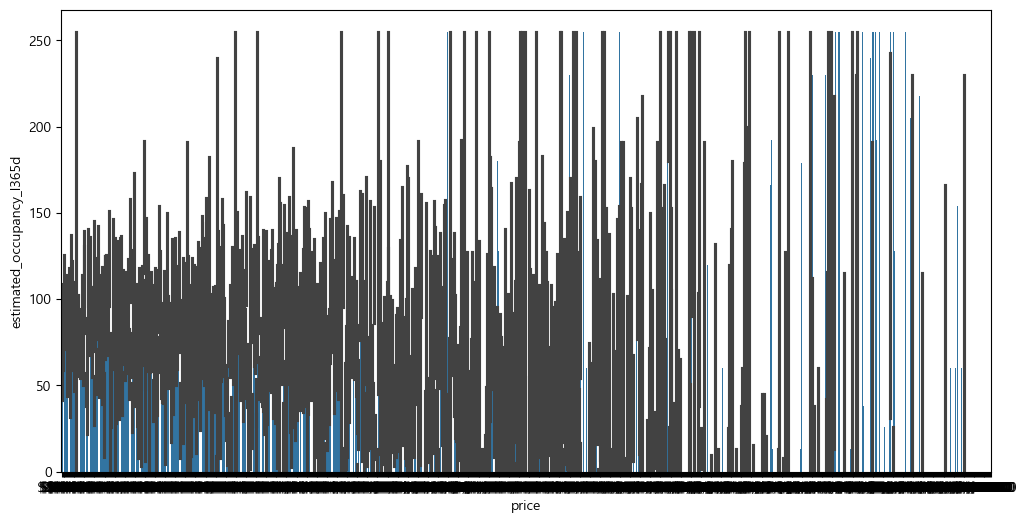

In [24]:
clean_df['estimated_occupancy_l365d'].value_counts()
sns.barplot(data=clean_df, x='price', y='estimated_occupancy_l365d')
plt.show()